In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

In [4]:
data=pd.read_csv("./data/fraud.csv")
data.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.970,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011,-82.048,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.888,-118.210,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159,-118.186,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.110,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.181,-112.262,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.151,-112.154,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.231,-112.114,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034,-112.561,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.960,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.421,-79.463,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.675,-78.632,0


In [5]:
data.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1852394 non-null  object 
 1   cc_num                 1852394 non-null  int64  
 2   merchant               1852394 non-null  object 
 3   category               1852394 non-null  object 
 4   amt                    1852394 non-null  float64
 5   first                  1852394 non-null  object 
 6   last                   1852394 non-null  object 
 7   gender                 1852394 non-null  object 
 8   street                 1852394 non-null  object 
 9   city                   1852394 non-null  object 
 10  state                  1852394 non-null  object 
 11  zip                    1852394 non-null  int64  
 12  lat                    1852394 non-null  float64
 13  long                   1852394 non-null  float64
 14  city_pop          

In [6]:
data[['amt','city_pop']].describe()

,amt,city_pop
count,1852394.000,1852394.000
mean,70.064,88643.675
std,159.254,301487.618
min,1.000,23.000
25%,9.640,741.000
50%,47.450,2443.000
75%,83.100,20328.000
max,28948.900,2906700.000


In [7]:
data.isna().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [8]:
obj_cols=data.select_dtypes(include='object')
num_cols=data.select_dtypes(exclude='object')

In [9]:
obj_cols.columns

Index(['trans_date_trans_time', 'merchant', 'category', 'first', 'last',
       'gender', 'street', 'city', 'state', 'job', 'dob', 'trans_num'],
      dtype='object')

In [10]:
for col in obj_cols:
    print("="*30, col, "="*30)
    print("nunique: ", obj_cols[col].nunique(), end="\n\n")
    print(obj_cols[col].value_counts(), end="\n\n")
    print(data[[col, 'is_fraud']].groupby(col).mean().sort_values(by='is_fraud', ascending=False), end="\n\n")

============================== trans_date_trans_time ==============================
nunique:  1819551

trans_date_trans_time
2019-04-22 16:02:01    4
2020-06-01 01:37:47    4
2020-06-02 12:47:07    4
2020-10-05 19:37:49    4
2020-12-13 17:53:47    4
                      ..
2019-01-01 00:41:45    1
2019-01-01 00:42:26    1
2019-01-01 00:43:38    1
2019-01-01 00:44:20    1
2020-12-31 23:50:17    1
Name: count, Length: 1819551, dtype: int64

                       is_fraud
trans_date_trans_time          
2019-09-11 22:58:11       1.000
2019-12-22 01:09:30       1.000
2019-02-12 23:49:17       1.000
2019-09-23 06:33:47       1.000
2019-05-03 04:38:52       1.000
...                         ...
2019-01-01 00:41:45       0.000
2019-01-01 00:42:26       0.000
2019-01-01 00:43:38       0.000
2019-01-01 00:44:20       0.000
2020-12-31 23:50:17       0.000

[1819551 rows x 1 columns]

============================== merchant ==============================
nunique:  693

merchant
fraud_Kilback LL

nunique:  984

dob
1977-03-23    8044
1988-09-15    6574
1981-08-29    6571
1955-05-06    5121
1960-01-13    4395
              ... 
1962-03-14       7
1944-06-17       7
1970-06-25       7
1932-05-09       7
1998-08-02       6
Name: count, Length: 984, dtype: int64

            is_fraud
dob                 
2001-07-17     1.000
2002-03-17     1.000
1925-08-29     1.000
1927-02-03     1.000
1944-05-30     1.000
...              ...
1949-10-04     0.000
1975-04-16     0.000
1973-10-19     0.000
1975-06-29     0.000
1930-02-28     0.000

[984 rows x 1 columns]

============================== trans_num ==============================
nunique:  1852394

trans_num
1765bb45b3aa3224b4cdcb6e7a96cee3    1
0b242abb623afc578575680df30655b9    1
1f76529f8574734946361c461b024d99    1
a1a22d70485983eac12b5b88dad1cf95    1
6b849c168bdad6f867558c3793159a81    1
                                   ..
413636e759663f264aae1819a4d4f231    1
8a6293af5ed278dea14448ded2685fea    1
baae0b096835c975857eea7e28dde

'trans_date_trans_time','merchant','category','gender','job'

In [14]:
from ydata_profiling import ProfileReport

C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:

profile = ProfileReport(data, title="Selected Features Profiling Report", explorative=True)

profile.to_file("is_fraud_eda.html")

Export report to file: 100%|█████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 33.41it/s]


* 집위치와 상점 위치가 서로 연관이 있다
* cc_num이 유일값이 999개다.


In [17]:
data['cc_num'].nunique()

999

is_fraud의 비율

In [18]:
data['is_fraud'].mean()*100

np.float64(0.5210014716091717)

# 카드별(고객) 거래 금액에서의 이상치 찾고 is_fraud와의 관계보기

In [13]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')

In [14]:
amt_desc=data.groupby(['cc_num'])['amt'].describe()
amt_desc

,count,mean,std,min,25%,50%,75%,max
cc_num,,,,,,,,
60416207185,2196.000,59.258,142.870,1.020,7.560,36.540,72.802,3437.460
60422928733,2200.000,65.483,92.043,1.010,9.075,51.405,87.085,1290.370
60423098130,738.000,96.376,1000.694,1.010,8.780,35.425,75.463,27119.770
60427851591,743.000,107.488,131.015,8.860,59.140,76.670,99.110,1164.360
60487002085,735.000,64.097,153.208,1.020,8.095,35.670,70.855,2758.460
...,...,...,...,...,...,...,...,...
4958589671582726883,2191.000,67.206,137.504,1.000,8.830,50.130,84.455,4292.860
4973530368125489546,1467.000,75.789,258.847,1.010,9.435,52.660,88.340,8749.440
4980323467523543940,736.000,70.709,119.903,1.010,8.465,42.515,83.458,1327.430


In [21]:
amt_desc['iqr_max']=amt_desc['75%']+(1.5*(amt_desc['75%']-amt_desc['25%']))
amt_desc

,count,mean,std,min,25%,50%,75%,max,iqr_max
cc_num,,,,,,,,,
60416207185,2196.000,59.258,142.870,1.020,7.560,36.540,72.802,3437.460,170.666
60422928733,2200.000,65.483,92.043,1.010,9.075,51.405,87.085,1290.370,204.100
60423098130,738.000,96.376,1000.694,1.010,8.780,35.425,75.463,27119.770,175.486
60427851591,743.000,107.488,131.015,8.860,59.140,76.670,99.110,1164.360,159.065
60487002085,735.000,64.097,153.208,1.020,8.095,35.670,70.855,2758.460,164.995
...,...,...,...,...,...,...,...,...,...
4958589671582726883,2191.000,67.206,137.504,1.000,8.830,50.130,84.455,4292.860,197.892
4973530368125489546,1467.000,75.789,258.847,1.010,9.435,52.660,88.340,8749.440,206.697
4980323467523543940,736.000,70.709,119.903,1.010,8.465,42.515,83.458,1327.430,195.946


In [22]:
amt_desc=amt_desc.reset_index()
amt_desc

,cc_num,count,mean,std,min,25%,50%,75%,max,iqr_max
0,60416207185,2196.000,59.258,142.870,1.020,7.560,36.540,72.802,3437.460,170.666
1,60422928733,2200.000,65.483,92.043,1.010,9.075,51.405,87.085,1290.370,204.100
2,60423098130,738.000,96.376,1000.694,1.010,8.780,35.425,75.463,27119.770,175.486
3,60427851591,743.000,107.488,131.015,8.860,59.140,76.670,99.110,1164.360,159.065
4,60487002085,735.000,64.097,153.208,1.020,8.095,35.670,70.855,2758.460,164.995
...,...,...,...,...,...,...,...,...,...,...
994,4958589671582726883,2191.000,67.206,137.504,1.000,8.830,50.130,84.455,4292.860,197.892
995,4973530368125489546,1467.000,75.789,258.847,1.010,9.435,52.660,88.340,8749.440,206.697
996,4980323467523543940,736.000,70.709,119.903,1.010,8.465,42.515,83.458,1327.430,195.946
997,4989847570577635369,1471.000,93.009,128.397,1.030,19.940,57.170,111.945,1223.850,249.952


# 원본 data와 그룹연산결과 합치기

In [23]:
amt_desc.columns = ['cc_num', 'count', 'amt_mean', 'amt_std', 'min', '25%', '50%', '75%', 'max',
       'amt_iqr_max']

In [24]:
data = pd.merge(data, amt_desc[['cc_num','amt_mean', 'amt_std', 'amt_iqr_max']], how='left', on='cc_num')
data

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,age,amt_mean,amt_std,amt_iqr_max
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.970,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011,-82.048,0,32,89.409,127.530,256.620
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.888,-118.210,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159,-118.186,0,42,56.078,159.202,158.060
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.110,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.181,-112.262,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.151,-112.154,0,58,69.924,116.689,210.800
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.231,-112.114,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034,-112.561,0,53,80.090,280.078,193.098
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.960,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.421,-79.463,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.675,-78.632,0,34,95.341,94.323,149.974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.770,Michael,Olson,M,558 Michael Estates,Luray,MO,63453,40.493,-91.891,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.947,-91.333,0,54,62.348,110.821,182.535
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.840,Jose,Vasquez,M,572 Davis Mountains,Lake Jackson,TX,77566,29.039,-95.440,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661,-96.187,0,21,50.452,168.361,136.045
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.880,Ann,Lawson,F,144 Evans Islands Apt. 683,Burbank,WA,99323,46.197,-118.902,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658,-119.715,0,39,88.704,119.949,261.548
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.990,Eric,Preston,M,7020 Doyle Stream Apt. 951,Mesa,ID,83643,44.626,-116.449,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.471,-117.081,0,55,60.998,89.526,186.940


In [25]:
data = data.drop(['first', 'last', 'street', 'city', 'state', 'zip', 'trans_num', 'unix_time'], axis=1)
data

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,age,amt_mean,amt_std,amt_iqr_max
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.970,F,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,36.011,-82.048,0,32,89.409,127.530,256.620
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,F,48.888,-118.210,149,Special educational needs teacher,1978-06-21,49.159,-118.186,0,42,56.078,159.202,158.060
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.110,M,42.181,-112.262,4154,Nature conservation officer,1962-01-19,43.151,-112.154,0,58,69.924,116.689,210.800
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000,M,46.231,-112.114,1939,Patent attorney,1967-01-12,47.034,-112.561,0,53,80.090,280.078,193.098
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.960,M,38.421,-79.463,99,Dance movement psychotherapist,1986-03-28,38.675,-78.632,0,34,95.341,94.323,149.974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.770,M,40.493,-91.891,519,Town planner,1966-02-13,39.947,-91.333,0,54,62.348,110.821,182.535
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.840,M,29.039,-95.440,28739,Futures trader,1999-12-27,29.661,-96.187,0,21,50.452,168.361,136.045
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.880,F,46.197,-118.902,3684,Musician,1981-11-29,46.658,-119.715,0,39,88.704,119.949,261.548
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.990,M,44.626,-116.449,129,Cartographer,1965-12-15,44.471,-117.081,0,55,60.998,89.526,186.940


In [26]:
data.loc[data['amt'] > data['amt_iqr_max'], 'is_fraud'].mean() * 100

np.float64(8.316776198481838)

# 사용금액의 z-score를 구한 후 사기 비율 계산
* z-score: (값-평균) / 표준편차 =-3>, 3>


In [27]:
data['amt_zscore'] = (data['amt'] - data['amt_mean']) / data['amt_std']

In [28]:
data[(data['amt_zscore'] < -3) | (data['amt_zscore'] > 3)]['is_fraud'].value_counts()

is_fraud
0    21725
1     4092
Name: count, dtype: int64

In [29]:
data[(data['amt_zscore'] < -3) | (data['amt_zscore'] > 3)]['is_fraud'].mean() * 100

np.float64(15.850021303792076)

# 사용자가 어디에 주로 지출하는가?
* 식품에 지출이 많은 사람이 레저용품에 지출을 갑자기 많이 한다? 
* 평소 지출하는 카테고리 혹은 가게가 아닌 경우
* 카드번호별, 카테고리별 지출평균, 표준편차

In [30]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'lat', 'long', 'city_pop', 'job', 'dob', 'merch_lat',
       'merch_long', 'is_fraud', 'age', 'amt_mean', 'amt_std', 'amt_iqr_max',
       'amt_zscore'],
      dtype='object')

In [31]:
cat_amt=data.groupby(['cc_num','category'])['amt'].agg(['mean','std']).reset_index()
cat_amt

,cc_num,category,mean,std
0,60416207185,entertainment,51.839,65.486
1,60416207185,food_dining,26.737,46.383
2,60416207185,gas_transport,59.779,15.758
3,60416207185,grocery_net,52.153,17.695
4,60416207185,grocery_pos,101.558,21.894
...,...,...,...,...
13166,4992346398065154184,misc_pos,60.003,167.226
13167,4992346398065154184,personal_care,48.777,49.524
13168,4992346398065154184,shopping_net,86.280,217.047
13169,4992346398065154184,shopping_pos,64.213,169.239


In [32]:
cat_amt.columns=['cc_num','category','cat_amt_mean','cat_amt_std']

In [33]:
cat_amt

,cc_num,category,cat_amt_mean,cat_amt_std
0,60416207185,entertainment,51.839,65.486
1,60416207185,food_dining,26.737,46.383
2,60416207185,gas_transport,59.779,15.758
3,60416207185,grocery_net,52.153,17.695
4,60416207185,grocery_pos,101.558,21.894
...,...,...,...,...
13166,4992346398065154184,misc_pos,60.003,167.226
13167,4992346398065154184,personal_care,48.777,49.524
13168,4992346398065154184,shopping_net,86.280,217.047
13169,4992346398065154184,shopping_pos,64.213,169.239


In [34]:
data=pd.merge(data, cat_amt, how='left', on=['cc_num','category'])
data

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,age,amt_mean,amt_std,amt_iqr_max,amt_zscore,cat_amt_mean,cat_amt_std
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.970,F,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,36.011,-82.048,0,32,89.409,127.530,256.620,-0.662,84.861,116.070
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,F,48.888,-118.210,149,Special educational needs teacher,1978-06-21,49.159,-118.186,0,42,56.078,159.202,158.060,0.321,99.637,23.904
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.110,M,42.181,-112.262,4154,Nature conservation officer,1962-01-19,43.151,-112.154,0,58,69.924,116.689,210.800,1.287,46.653,60.385
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000,M,46.231,-112.114,1939,Patent attorney,1967-01-12,47.034,-112.561,0,53,80.090,280.078,193.098,-0.125,61.537,15.747
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.960,M,38.421,-79.463,99,Dance movement psychotherapist,1986-03-28,38.675,-78.632,0,34,95.341,94.323,149.974,-0.566,35.481,4.935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.770,M,40.493,-91.891,519,Town planner,1966-02-13,39.947,-91.333,0,54,62.348,110.821,182.535,-0.168,45.931,45.150
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.840,M,29.039,-95.440,28739,Futures trader,1999-12-27,29.661,-96.187,0,21,50.452,168.361,136.045,0.365,50.924,52.342
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.880,F,46.197,-118.902,3684,Musician,1981-11-29,46.658,-119.715,0,39,88.704,119.949,261.548,-0.015,63.857,52.309
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.990,M,44.626,-116.449,129,Cartographer,1965-12-15,44.471,-117.081,0,55,60.998,89.526,186.940,-0.592,8.192,27.244


In [35]:
data['cat_amt_zscore']=(data['amt']-data['cat_amt_mean'])/data['cat_amt_std']

In [36]:
data[(data['cat_amt_zscore']<-3) | (data['cat_amt_zscore']>3)]['is_fraud'].mean() * 100

np.float64(19.290895447723862)

In [37]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'lat', 'long', 'city_pop', 'job', 'dob', 'merch_lat',
       'merch_long', 'is_fraud', 'age', 'amt_mean', 'amt_std', 'amt_iqr_max',
       'amt_zscore', 'cat_amt_mean', 'cat_amt_std', 'cat_amt_zscore'],
      dtype='object')

# geopy 를 이용해 위도 경도 정보로 집과 가게의 거리 계산하기

In [41]:
from haversine import haversine, Unit

In [43]:
def calc_distance(row):
    home=(row['lat'], row['long'])
    store = (row['merch_lat'], row['merch_long'])
    return haversine(home, store, unit=Unit.KILOMETERS)

data['home_merch_dist'] = data.apply(calc_distance, axis=1)

In [44]:
dist_desc = data.groupby(['cc_num'])['home_merch_dist'].agg(['mean', 'std']).reset_index()
dist_desc

,cc_num,mean,std
0,60416207185,73.501,28.706
1,60422928733,79.028,29.333
2,60423098130,77.843,28.217
3,60427851591,75.732,29.007
4,60487002085,79.494,28.803
...,...,...,...
994,4958589671582726883,76.735,29.145
995,4973530368125489546,78.775,29.478
996,4980323467523543940,72.231,28.287
997,4989847570577635369,77.005,29.423


In [45]:
dist_desc.columns = ['cc_num', 'dist_mean', 'dist_std']
dist_desc

,cc_num,dist_mean,dist_std
0,60416207185,73.501,28.706
1,60422928733,79.028,29.333
2,60423098130,77.843,28.217
3,60427851591,75.732,29.007
4,60487002085,79.494,28.803
...,...,...,...
994,4958589671582726883,76.735,29.145
995,4973530368125489546,78.775,29.478
996,4980323467523543940,72.231,28.287
997,4989847570577635369,77.005,29.423


In [46]:
data = pd.merge(data, dist_desc, how='left', on='cc_num')
data

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,age,amt_mean,amt_std,amt_iqr_max,amt_zscore,cat_amt_mean,cat_amt_std,cat_amt_zscore,distance,home_merch_dist,dist_mean,dist_std
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.970,F,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,36.011,-82.048,0,32,89.409,127.530,256.620,-0.662,84.861,116.070,-0.688,78.598,78.598,77.864,30.101
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,F,48.888,-118.210,149,Special educational needs teacher,1978-06-21,49.159,-118.186,0,42,56.078,159.202,158.060,0.321,99.637,23.904,0.318,30.212,30.212,71.579,28.081
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.110,M,42.181,-112.262,4154,Nature conservation officer,1962-01-19,43.151,-112.154,0,58,69.924,116.689,210.800,1.287,46.653,60.385,2.873,108.206,108.206,74.556,28.894
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000,M,46.231,-112.114,1939,Patent attorney,1967-01-12,47.034,-112.561,0,53,80.090,280.078,193.098,-0.125,61.537,15.747,-1.050,95.673,95.673,71.993,28.892
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.960,M,38.421,-79.463,99,Dance movement psychotherapist,1986-03-28,38.675,-78.632,0,34,95.341,94.323,149.974,-0.566,35.481,4.935,1.313,77.557,77.557,75.838,29.177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.770,M,40.493,-91.891,519,Town planner,1966-02-13,39.947,-91.333,0,54,62.348,110.821,182.535,-0.168,45.931,45.150,-0.048,77.026,77.026,75.511,28.976
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.840,M,29.039,-95.440,28739,Futures trader,1999-12-27,29.661,-96.187,0,21,50.452,168.361,136.045,0.365,50.924,52.342,1.164,100.075,100.075,79.251,30.098
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.880,F,46.197,-118.902,3684,Musician,1981-11-29,46.658,-119.715,0,39,88.704,119.949,261.548,-0.015,63.857,52.309,0.440,80.759,80.759,72.600,28.551
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.990,M,44.626,-116.449,129,Cartographer,1965-12-15,44.471,-117.081,0,55,60.998,89.526,186.940,-0.592,8.192,27.244,-0.007,52.933,52.933,73.642,28.260


In [47]:
data['dist_zscore'] = (data['home_merch_dist'] - data['dist_mean']) / data['dist_std']

In [48]:
data[(data['dist_zscore'] < -3) | (data['dist_zscore'] > 3)]

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,age,amt_mean,amt_std,amt_iqr_max,amt_zscore,cat_amt_mean,cat_amt_std,cat_amt_zscore,distance,home_merch_dist,dist_mean,dist_std,dist_zscore


In [52]:
data = data.drop(['cc_num', 'merchant', 'amt_mean', 'amt_std', 'cat_amt_mean', 'cat_amt_std',
          'dist_mean', 'dist_std', 'lat', 'long',
           'merch_lat', 'merch_long'], axis=1)

KeyError: "['cc_num', 'merchant', 'amt_mean', 'amt_std', 'cat_amt_mean', 'cat_amt_std', 'dist_mean', 'dist_std', 'lat', 'long', 'merch_lat', 'merch_long'] not found in axis"

In [53]:
data.columns

Index(['trans_date_trans_time', 'category', 'amt', 'gender', 'city_pop', 'job',
       'dob', 'is_fraud', 'age', 'amt_iqr_max', 'amt_zscore', 'cat_amt_zscore',
       'distance', 'home_merch_dist', 'dist_zscore'],
      dtype='object')

In [55]:
data=data.drop(['distance'], axis=1)

# 나이 추출

In [56]:
data['trans_date_trans_time'][-1:][1852393][:4]

'2020'

In [57]:
data['age'] = data['dob'].apply(lambda x: 2020 - int(x[:4]))

<Axes: ylabel='Frequency'>

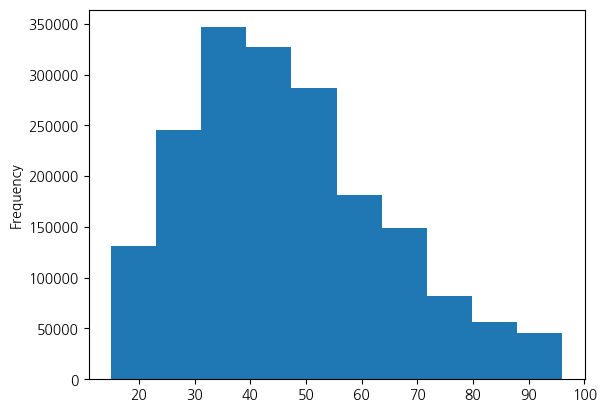

In [58]:
data['age'].plot(kind='hist')

In [59]:
data.groupby('age')['is_fraud'].mean().sort_values(ascending=False)

age
18   1.000
95   1.000
88   0.016
77   0.012
80   0.012
24   0.011
86   0.010
63   0.010
96   0.010
57   0.009
83   0.009
59   0.009
52   0.009
79   0.009
93   0.008
56   0.008
84   0.008
82   0.007
19   0.007
81   0.007
78   0.007
71   0.007
92   0.007
62   0.007
60   0.007
68   0.007
87   0.007
73   0.007
74   0.007
64   0.006
53   0.006
58   0.006
61   0.006
85   0.006
34   0.006
89   0.006
54   0.006
72   0.006
75   0.006
91   0.006
51   0.006
50   0.006
20   0.006
67   0.006
70   0.006
22   0.006
55   0.005
38   0.005
25   0.005
29   0.005
23   0.005
21   0.005
27   0.005
26   0.005
30   0.005
66   0.005
44   0.005
76   0.005
90   0.004
39   0.004
43   0.004
33   0.004
69   0.004
65   0.004
46   0.004
28   0.004
37   0.004
31   0.004
49   0.004
48   0.004
94   0.004
41   0.004
47   0.004
17   0.004
32   0.004
42   0.003
40   0.003
35   0.003
36   0.003
45   0.003
16   0.003
15   0.002
Name: is_fraud, dtype: float64

In [60]:
data['age'].value_counts()

age
48    65036
36    56964
33    53377
35    53335
46    48984
44    46820
34    45422
30    44601
47    44536
32    43853
42    43829
23    43178
45    43112
27    41732
49    39490
40    38716
50    36614
37    35834
43    35828
31    35816
29    35108
54    33692
58    32961
53    32230
51    29293
25    29289
38    29284
39    28531
26    28527
65    27804
21    27057
55    26364
41    25592
60    24934
59    24256
52    24241
64    24170
56    22740
66    22679
61    21976
28    21930
57    19109
62    19061
22    19040
75    17569
63    16884
68    15386
70    15385
67    15373
71    13925
20    13918
72    13913
69    13896
74    13188
78    11727
16    10967
81    10259
79     9531
85     9526
80     8844
24     8824
84     8798
91     8795
94     8783
19     8082
93     6601
89     6589
76     6580
92     5852
17     5833
77     5164
86     5152
83     5143
90     5114
82     4404
73     4400
87     4399
88     2965
15     2922
96      735
18       12
95       11
Name: count,

In [61]:
data = data.drop(['trans_date_trans_time', 'dob' ], axis=1)

# 종속변수, 독립변수 분리/ 훈련, 테스트 데이터로 나누기

In [62]:
X = data.drop('is_fraud', axis=1)
y = data['is_fraud']

In [63]:
X=pd.get_dummies(X, drop_first=True)

In [64]:
X

,amt,city_pop,age,amt_iqr_max,amt_zscore,cat_amt_zscore,home_merch_dist,dist_zscore,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,gender_M,"job_Accountant, chartered","job_Accountant, chartered certified","job_Accountant, chartered public finance",job_Accounting technician,job_Acupuncturist,job_Administrator,"job_Administrator, arts","job_Administrator, charities/voluntary organisations","job_Administrator, education","job_Administrator, local government",job_Advertising account executive,job_Advertising account planner,job_Advertising copywriter,job_Advice worker,job_Aeronautical engineer,job_Agricultural consultant,job_Aid worker,job_Air broker,job_Air cabin crew,job_Air traffic controller,job_Airline pilot,job_Ambulance person,job_Amenity horticulturist,job_Analytical chemist,job_Animal nutritionist,job_Animal technologist,job_Animator,job_Applications developer,job_Arboriculturist,job_Archaeologist,job_Architect,job_Architectural technologist,job_Archivist,job_Armed forces logistics/support/administrative officer,job_Armed forces technical officer,job_Armed forces training and education officer,job_Art gallery manager,job_Art therapist,job_Artist,job_Arts development officer,job_Associate Professor,job_Audiological scientist,job_Barista,job_Barrister,job_Barrister's clerk,"job_Biochemist, clinical",job_Biomedical engineer,job_Biomedical scientist,job_Bookseller,job_Broadcast engineer,job_Broadcast journalist,job_Broadcast presenter,job_Building control surveyor,job_Building services engineer,job_Building surveyor,"job_Buyer, industrial","job_Buyer, retail",job_Cabin crew,job_Call centre manager,job_Camera operator,job_Careers adviser,job_Careers information officer,job_Cartographer,job_Catering manager,job_Ceramics designer,job_Charity fundraiser,job_Charity officer,job_Chartered accountant,job_Chartered legal executive (England and Wales),job_Chartered loss adjuster,job_Chartered public finance accountant,job_Chemical engineer,"job_Chemist, analytical",job_Chief Executive Officer,job_Chief Financial Officer,job_Chief Marketing Officer,job_Chief Operating Officer,job_Chief Strategy Officer,job_Chief Technology Officer,job_Chief of Staff,job_Child psychotherapist,job_Chiropodist,job_Civil Service administrator,job_Civil Service fast streamer,"job_Civil engineer, contracting",job_Claims inspector/assessor,job_Clinical biochemist,job_Clinical cytogeneticist,job_Clinical psychologist,job_Clinical research associate,job_Clothing/textile technologist,job_Colour technologist,job_Commercial horticulturist,job_Commercial/residential surveyor,job_Commissioning editor,job_Communications engineer,job_Community arts worker,job_Community development worker,job_Community education officer,job_Community pharmacist,job_Company secretary,job_Comptroller,"job_Conservation officer, historic buildings","job_Conservator, furniture","job_Conservator, museum/gallery",job_Contracting civil engineer,job_Contractor,job_Control and instrumentation engineer,job_Copy,"job_Copywriter, advertising",job_Corporate investment banker,job_Counselling psychologist,job_Counsellor,job_Curator,job_Cytogeneticist,job_Dance movement psychotherapist,job_Dancer,job_Data scientist,job_Database administrator,job_Dealer,"job_Designer, ceramics/pottery","job_Designer, exhibition/display","job_Designer, furniture","job_Designer, industrial/product","job_Designer, interior/spatial","job_Designer, jewellery","job_Designer, multimedia","job_Designer, television/film set","job_Designer, textile","job_Development worker, community","job_Development worker, international aid",job_Diagnostic radiographer,job_Dispensing optician,"job_Doctor, general practice","job_Doctor, hospital",job_Drilling engineer,job_Early years teacher,job_Ecologist,job_Economist,"job_Editor, 

In [65]:
y

0          0
1          0
2          0
3          0
4          0
          ..
1852389    0
1852390    0
1852391    0
1852392    0
1852393    0
Name: is_fraud, Length: 1852394, dtype: int64

In [66]:
y.value_counts()

is_fraud
0    1842743
1       9651
Name: count, dtype: int64

In [69]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

* 홀드아웃, train, valid, test: 데이터 충분할 때 할 수 있는 방법

In [70]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.4, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_valid, y_valid, test_size=0.5, stratify=y_valid, random_state=42)

의사결정 나무로 분석하기

In [75]:
for i in range(1, 11):
    dtc = DecisionTreeClassifier(max_depth=i, class_weight='balanced', random_state=42)
    dtc.fit(X_train, y_train)
    pred = dtc.predict(X_valid)
    print(classification_report(y_valid, pred))
    print("=" * 30, f"test_result {i}", "=" * 30)
    test_pred = dtc.predict(X_test)
    print(classification_report(y_test, test_pred))
    print()

              precision    recall  f1-score   support

           0       1.00      0.97      0.99    368549
           1       0.12      0.75      0.21      1930

    accuracy                           0.97    370479
   macro avg       0.56      0.86      0.60    370479
weighted avg       0.99      0.97      0.98    370479

============================== test_result 1 ==============================
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    368549
           1       0.12      0.76      0.21      1930

    accuracy                           0.97    370479
   macro avg       0.56      0.87      0.60    370479
weighted avg       0.99      0.97      0.98    370479


              precision    recall  f1-score   support

           0       1.00      0.97      0.99    368549
           1       0.15      0.84      0.25      1930

    accuracy                           0.97    370479
   macro avg       0.57      0.91      0.62    3704

In [76]:
importance=pd.DataFrame(dtc.feature_importances_, columns=['importance'])
column_name=pd.DataFrame(dtc.feature_names_in_, columns=['column'])

In [77]:
dtc_im_col = pd.concat([column_name, importance], axis=1)

In [78]:
dtc_im_col.sort_values(by='importance', ascending=False)

,column,importance
0,amt,0.709
5,cat_amt_zscore,0.158
2,age,0.017
20,category_travel,0.015
8,category_food_dining,0.014
...,...,...
513,job_Water engineer,0.000
514,job_Water quality scientist,0.000
515,job_Web designer,0.000
516,job_Wellsite geologist,0.000


random_forest로 분석하기

In [79]:
rfc= RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=10)
rfc.fit(X_train, y_train)
pred=rfc.predict(X_valid)
print("="*30, "valid_result", "="*30)
print(classification_report(y_valid, pred), end="\n\n")

print("="*30, "test_result", "="*30)
test_pred=rfc.predict(X_test)
print(classification_report(y_test, test_pred), end="\n\n")

============================== valid_result ==============================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368549
           1       0.86      0.65      0.74      1930

    accuracy                           1.00    370479
   macro avg       0.93      0.82      0.87    370479
weighted avg       1.00      1.00      1.00    370479


============================== test_result ==============================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368549
           1       0.86      0.63      0.73      1930

    accuracy                           1.00    370479
   macro avg       0.93      0.81      0.86    370479
weighted avg       1.00      1.00      1.00    370479




XGBOOST로 분석하기

In [80]:
y_train.value_counts()

is_fraud
0    1105645
1       5791
Name: count, dtype: int64

## XGBoost에서 소수 클래스에 가중치줄 때 값 계산
* n_negative / n_positive
* scale_pos_weight=n_negative/n_positive

In [82]:
%%time
xgb=XGBClassifier(scale_pos_weight=190, n_jobs=10, random_state=42)
xgb.fit(X_train, y_train)
pred=xgb.predict(X_valid)
print("="*30, "valid_result", "="*30)
print(classification_report(y_valid, pred), end="\n\n")

print("="*30, "test_result", "="*30)
test_pred=xgb.predict(X_test)
print(classification_report(y_test, test_pred), end="\n\n")

============================== valid_result ==============================
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    368549
           1       0.19      0.94      0.32      1930

    accuracy                           0.98    370479
   macro avg       0.60      0.96      0.65    370479
weighted avg       1.00      0.98      0.99    370479


============================== test_result ==============================
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    368549
           1       0.20      0.95      0.33      1930

    accuracy                           0.98    370479
   macro avg       0.60      0.97      0.66    370479
weighted avg       1.00      0.98      0.99    370479


CPU times: total: 5min 17s
Wall time: 1min 16s


# catboost

In [90]:
%%time
cbc=CatBoostClassifier(class_weights=[1, 190], thread_count=10, random_state=42)
cbc.fit(X_train, y_train)
pred=cbc.predict(X_valid)
print("="*30, "valid_result", "="*30)
print(classification_report(y_valid, pred), end="\n\n")

print("="*30, "test_result", "="*30)
test_pred=cbc.predict(X_test)
print(classification_report(y_test, test_pred), end="\n\n")

Learning rate set to 0.205839
0:	learn: 0.4740099	total: 121ms	remaining: 2m 1s
1:	learn: 0.3744950	total: 240ms	remaining: 1m 59s
2:	learn: 0.2999325	total: 376ms	remaining: 2m 5s
3:	learn: 0.2590463	total: 508ms	remaining: 2m 6s
4:	learn: 0.2248208	total: 649ms	remaining: 2m 9s
5:	learn: 0.2055894	total: 818ms	remaining: 2m 15s
6:	learn: 0.1882242	total: 996ms	remaining: 2m 21s
7:	learn: 0.1754144	total: 1.13s	remaining: 2m 20s
8:	learn: 0.1679504	total: 1.27s	remaining: 2m 19s
9:	learn: 0.1615141	total: 1.39s	remaining: 2m 17s
10:	learn: 0.1546167	total: 1.48s	remaining: 2m 12s
11:	learn: 0.1495882	total: 1.59s	remaining: 2m 10s
12:	learn: 0.1429293	total: 1.7s	remaining: 2m 9s
13:	learn: 0.1355097	total: 1.8s	remaining: 2m 7s
14:	learn: 0.1318382	total: 1.9s	remaining: 2m 4s
15:	learn: 0.1286162	total: 2.02s	remaining: 2m 4s
16:	learn: 0.1258042	total: 2.13s	remaining: 2m 2s
17:	learn: 0.1219601	total: 2.25s	remaining: 2m 2s
18:	learn: 0.1186378	total: 2.38s	remaining: 2m 2s
19:	le

159:	learn: 0.0503914	total: 25.9s	remaining: 2m 16s
160:	learn: 0.0502960	total: 26.1s	remaining: 2m 15s
161:	learn: 0.0501837	total: 26.2s	remaining: 2m 15s
162:	learn: 0.0500865	total: 26.4s	remaining: 2m 15s
163:	learn: 0.0498643	total: 26.6s	remaining: 2m 15s
164:	learn: 0.0497897	total: 26.7s	remaining: 2m 15s
165:	learn: 0.0496764	total: 26.9s	remaining: 2m 14s
166:	learn: 0.0496256	total: 27s	remaining: 2m 14s
167:	learn: 0.0495386	total: 27.1s	remaining: 2m 14s
168:	learn: 0.0494075	total: 27.3s	remaining: 2m 14s
169:	learn: 0.0493304	total: 27.4s	remaining: 2m 13s
170:	learn: 0.0491766	total: 27.5s	remaining: 2m 13s
171:	learn: 0.0489803	total: 27.7s	remaining: 2m 13s
172:	learn: 0.0489176	total: 27.8s	remaining: 2m 12s
173:	learn: 0.0487849	total: 27.9s	remaining: 2m 12s
174:	learn: 0.0486963	total: 28.1s	remaining: 2m 12s
175:	learn: 0.0485673	total: 28.2s	remaining: 2m 12s
176:	learn: 0.0484128	total: 28.4s	remaining: 2m 11s
177:	learn: 0.0483143	total: 28.5s	remaining: 2m

317:	learn: 0.0357147	total: 50.2s	remaining: 1m 47s
318:	learn: 0.0356420	total: 50.3s	remaining: 1m 47s
319:	learn: 0.0355768	total: 50.5s	remaining: 1m 47s
320:	learn: 0.0355104	total: 50.6s	remaining: 1m 47s
321:	learn: 0.0354386	total: 50.8s	remaining: 1m 46s
322:	learn: 0.0353459	total: 50.9s	remaining: 1m 46s
323:	learn: 0.0353193	total: 51.1s	remaining: 1m 46s
324:	learn: 0.0353002	total: 51.2s	remaining: 1m 46s
325:	learn: 0.0352517	total: 51.4s	remaining: 1m 46s
326:	learn: 0.0352042	total: 51.5s	remaining: 1m 46s
327:	learn: 0.0351643	total: 51.7s	remaining: 1m 45s
328:	learn: 0.0351009	total: 51.8s	remaining: 1m 45s
329:	learn: 0.0350175	total: 52s	remaining: 1m 45s
330:	learn: 0.0349508	total: 52.2s	remaining: 1m 45s
331:	learn: 0.0348959	total: 52.3s	remaining: 1m 45s
332:	learn: 0.0348279	total: 52.5s	remaining: 1m 45s
333:	learn: 0.0347872	total: 52.6s	remaining: 1m 44s
334:	learn: 0.0345507	total: 52.8s	remaining: 1m 44s
335:	learn: 0.0344816	total: 53s	remaining: 1m 4

473:	learn: 0.0288109	total: 1m 14s	remaining: 1m 22s
474:	learn: 0.0288107	total: 1m 14s	remaining: 1m 22s
475:	learn: 0.0288107	total: 1m 14s	remaining: 1m 22s
476:	learn: 0.0288104	total: 1m 15s	remaining: 1m 22s
477:	learn: 0.0288104	total: 1m 15s	remaining: 1m 22s
478:	learn: 0.0287799	total: 1m 15s	remaining: 1m 21s
479:	learn: 0.0287463	total: 1m 15s	remaining: 1m 21s
480:	learn: 0.0287162	total: 1m 15s	remaining: 1m 21s
481:	learn: 0.0286875	total: 1m 15s	remaining: 1m 21s
482:	learn: 0.0286754	total: 1m 15s	remaining: 1m 21s
483:	learn: 0.0286214	total: 1m 16s	remaining: 1m 21s
484:	learn: 0.0285630	total: 1m 16s	remaining: 1m 20s
485:	learn: 0.0285498	total: 1m 16s	remaining: 1m 20s
486:	learn: 0.0285190	total: 1m 16s	remaining: 1m 20s
487:	learn: 0.0284618	total: 1m 16s	remaining: 1m 20s
488:	learn: 0.0284602	total: 1m 16s	remaining: 1m 20s
489:	learn: 0.0284602	total: 1m 17s	remaining: 1m 20s
490:	learn: 0.0284601	total: 1m 17s	remaining: 1m 20s
491:	learn: 0.0284600	total:

627:	learn: 0.0242168	total: 1m 37s	remaining: 57.7s
628:	learn: 0.0241797	total: 1m 37s	remaining: 57.5s
629:	learn: 0.0241725	total: 1m 37s	remaining: 57.3s
630:	learn: 0.0241107	total: 1m 37s	remaining: 57.2s
631:	learn: 0.0240883	total: 1m 37s	remaining: 57s
632:	learn: 0.0240768	total: 1m 38s	remaining: 56.9s
633:	learn: 0.0240727	total: 1m 38s	remaining: 56.7s
634:	learn: 0.0240376	total: 1m 38s	remaining: 56.5s
635:	learn: 0.0240096	total: 1m 38s	remaining: 56.4s
636:	learn: 0.0239836	total: 1m 38s	remaining: 56.2s
637:	learn: 0.0239699	total: 1m 38s	remaining: 56.1s
638:	learn: 0.0239515	total: 1m 39s	remaining: 56s
639:	learn: 0.0239265	total: 1m 39s	remaining: 55.9s
640:	learn: 0.0238644	total: 1m 39s	remaining: 55.8s
641:	learn: 0.0238466	total: 1m 39s	remaining: 55.6s
642:	learn: 0.0238207	total: 1m 39s	remaining: 55.5s
643:	learn: 0.0238206	total: 1m 40s	remaining: 55.3s
644:	learn: 0.0237955	total: 1m 40s	remaining: 55.2s
645:	learn: 0.0237890	total: 1m 40s	remaining: 55.

783:	learn: 0.0206625	total: 2m 2s	remaining: 33.8s
784:	learn: 0.0206427	total: 2m 2s	remaining: 33.6s
785:	learn: 0.0206420	total: 2m 2s	remaining: 33.4s
786:	learn: 0.0206274	total: 2m 3s	remaining: 33.3s
787:	learn: 0.0206068	total: 2m 3s	remaining: 33.1s
788:	learn: 0.0205918	total: 2m 3s	remaining: 33s
789:	learn: 0.0205557	total: 2m 3s	remaining: 32.8s
790:	learn: 0.0205281	total: 2m 3s	remaining: 32.7s
791:	learn: 0.0205042	total: 2m 3s	remaining: 32.5s
792:	learn: 0.0205041	total: 2m 3s	remaining: 32.4s
793:	learn: 0.0204997	total: 2m 4s	remaining: 32.2s
794:	learn: 0.0204829	total: 2m 4s	remaining: 32s
795:	learn: 0.0204823	total: 2m 4s	remaining: 31.9s
796:	learn: 0.0204686	total: 2m 4s	remaining: 31.7s
797:	learn: 0.0204650	total: 2m 4s	remaining: 31.6s
798:	learn: 0.0204506	total: 2m 4s	remaining: 31.4s
799:	learn: 0.0204304	total: 2m 4s	remaining: 31.2s
800:	learn: 0.0204251	total: 2m 5s	remaining: 31.1s
801:	learn: 0.0204248	total: 2m 5s	remaining: 30.9s
802:	learn: 0.02

941:	learn: 0.0189320	total: 2m 25s	remaining: 8.98s
942:	learn: 0.0189108	total: 2m 26s	remaining: 8.83s
943:	learn: 0.0189108	total: 2m 26s	remaining: 8.67s
944:	learn: 0.0189106	total: 2m 26s	remaining: 8.52s
945:	learn: 0.0189106	total: 2m 26s	remaining: 8.36s
946:	learn: 0.0189106	total: 2m 26s	remaining: 8.2s
947:	learn: 0.0188951	total: 2m 26s	remaining: 8.05s
948:	learn: 0.0188951	total: 2m 26s	remaining: 7.89s
949:	learn: 0.0188950	total: 2m 27s	remaining: 7.74s
950:	learn: 0.0188942	total: 2m 27s	remaining: 7.58s
951:	learn: 0.0188765	total: 2m 27s	remaining: 7.43s
952:	learn: 0.0188640	total: 2m 27s	remaining: 7.27s
953:	learn: 0.0188561	total: 2m 27s	remaining: 7.12s
954:	learn: 0.0188533	total: 2m 27s	remaining: 6.96s
955:	learn: 0.0188441	total: 2m 27s	remaining: 6.81s
956:	learn: 0.0188240	total: 2m 28s	remaining: 6.65s
957:	learn: 0.0188092	total: 2m 28s	remaining: 6.5s
958:	learn: 0.0187985	total: 2m 28s	remaining: 6.34s
959:	learn: 0.0187985	total: 2m 28s	remaining: 6

# lgbm

In [93]:
new_cols=[]
for idx, col in enumerate(X.columns):
    new_cols.append(col.replace(" ","_").replace("/","_").replace(",","_").replace(")","").replace("(","").replace("'",""))

In [95]:
print(len(new_cols))
print(len(X.columns))

518
518


In [96]:
X.columns=new_cols
X.columns

Index(['amt', 'city_pop', 'age', 'amt_iqr_max', 'amt_zscore', 'cat_amt_zscore',
       'home_merch_dist', 'dist_zscore', 'category_food_dining',
       'category_gas_transport',
       ...
       'job_Visual_merchandiser', 'job_Volunteer_coordinator',
       'job_Warden_ranger', 'job_Warehouse_manager',
       'job_Waste_management_officer', 'job_Water_engineer',
       'job_Water_quality_scientist', 'job_Web_designer',
       'job_Wellsite_geologist', 'job_Writer'],
      dtype='object', length=518)

In [97]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.4, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_valid, y_valid, test_size=0.5, stratify=y_valid, random_state=42)

In [99]:
%%time
lgbm=LGBMClassifier(class_weights="balanced", n_jobs=10, random_state=42)
lgbm.fit(X_train, y_train)
pred=lgbm.predict(X_valid)
print("="*30, "valid_result", "="*30)
print(classification_report(y_valid, pred), end="\n\n")

print("="*30, "test_result", "="*30)
test_pred=lgbm.predict(X_test)
print(classification_report(y_test, test_pred), end="\n\n")

[LightGBM] [Warning] Unknown parameter: class_weights
[LightGBM] [Warning] Unknown parameter: class_weights
[LightGBM] [Info] Number of positive: 5791, number of negative: 1105645
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020308 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2837
[LightGBM] [Info] Number of data points in the train set: 1111436, number of used features: 497
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005210 -> initscore=-5.251879
[LightGBM] [Info] Start training from score -5.251879
[LightGBM] [Warning] Unknown parameter: class_weights
============================== valid_result ==============================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368549
           1       0.64      0.62      0.63      1930

    accuracy                         

In [84]:
data.columns

Index(['category', 'amt', 'gender', 'city_pop', 'job', 'is_fraud', 'age',
       'amt_iqr_max', 'amt_zscore', 'cat_amt_zscore', 'home_merch_dist',
       'dist_zscore'],
      dtype='object')

In [85]:
X_train.columns

Index(['amt', 'city_pop', 'age', 'amt_iqr_max', 'amt_zscore', 'cat_amt_zscore',
       'home_merch_dist', 'dist_zscore', 'category_food_dining',
       'category_gas_transport',
       ...
       'job_Visual merchandiser', 'job_Volunteer coordinator',
       'job_Warden/ranger', 'job_Warehouse manager',
       'job_Waste management officer', 'job_Water engineer',
       'job_Water quality scientist', 'job_Web designer',
       'job_Wellsite geologist', 'job_Writer'],
      dtype='object', length=518)

# 랜덤포레스트로 하이퍼파라미터 튜닝하기

In [100]:
rfc= RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=10)

In [101]:
params=dict(criterion=['gini','entropy','log_loss'], 
            max_depth=[150, 160, 170, 180, 200],
            random_state=[42],
            class_weight=[None,'balanced'])

In [ ]:
%%time
rand_cv= RandomizedSearchCV(rfc, param_distributions=params, scoring='f1',cv=5, n_jobs=10, random_state=42)

rand_cv.fit(X_train, y_train)
pred=rand_cv.predict(X_valid)
print("="*30, "valid_result", "="*30)
print("best_params: ", grid_cv.best_params_)
print("best_score_: ", grid_cv.best_score_)
print(classification_report(y_valid, pred), end="\n\n")

print("="*30, "test_result", "="*30)
test_pred=rand_cv.predict(X_test)
print(classification_report(y_test, test_pred), end="\n\n")